# Analyse this naive k curve - constant k

- get average endpoints, average hashes, average reductions

## Imports

In [51]:
import numpy as np
import pandas as pd

t = 10000

## Get data 

In [52]:
## cherry m values
cherry_m_values = []

# read in from each directory the m_values and append to cherry_m_values
for i in range(10):
    # Assuming m_values are stored in a file named 'm_values_{i}.npy'
    m_values = np.load(f't_{t}/trial_{i}/m_values.npy')
    cherry_m_values.append(m_values)


## vanilla m values
vanilla_m_values = []
for i in range(10):
    m_values = np.load(f'../vanilla/t_{t}/trial_{i}/m_values.npy')
    vanilla_m_values.append(m_values)

In [53]:
# create dataframe with columns "table", "avg. endpoints", "avg. hashes", "avg. reductions"
df = pd.DataFrame(columns=["table", "avg. endpoints", "avg. hashes", "avg. reductions"])

## get cherry data first
cherry_avg_mt = np.mean([cherry[-1] for cherry in cherry_m_values])
cherry_avg_hashes = np.mean([np.sum(cherry[:-1]) for cherry in cherry_m_values])
cherry_avg_reductions = np.mean([np.sum(cherry[:-1] * 100) for cherry in cherry_m_values])  # since k_i = 100
# df = df.concat({"table": "cherry", "avg. endpoints": cherry_avg_mt, "avg. hashes": cherry_avg_hashes, "avg. reductions": cherry_avg_reductions}, ignore_index=True)
new_row = pd.DataFrame([{
    "table": "cherry", 
    "avg. endpoints": cherry_avg_mt, 
    "avg. hashes": cherry_avg_hashes, 
    "avg. reductions": cherry_avg_reductions
}])

df = pd.concat([df, new_row], ignore_index=True)

## get vanilla data
vanilla_avg_mt = np.mean([vanilla[-1] for vanilla in vanilla_m_values])
vanilla_avg_hashes = np.mean([np.sum(vanilla[:-1]) for vanilla in vanilla_m_values])
vanilla_avg_reductions = np.mean([np.sum(vanilla[:-1]) for vanilla in vanilla_m_values])  # since k_i = 1
# df = df.append({"table": "vanilla", "avg. endpoints": vanilla_avg_mt, "avg. hashes": vanilla_avg_hashes, "avg. reductions": vanilla_avg_reductions}, ignore_index=True)
new_row = pd.DataFrame([{
    "table": "vanilla", 
    "avg. endpoints": vanilla_avg_mt, 
    "avg. hashes": vanilla_avg_hashes, 
    "avg. reductions": vanilla_avg_reductions
}])

df = pd.concat([df, new_row], ignore_index=True)

display(df)

C:\Users\psymf9\AppData\Local\Temp\ipykernel_40176\790874731.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


,table,avg. endpoints,avg. hashes,avg. reductions
0,cherry,11091.4,118328549.6,1.183285e+10
1,vanilla,2670.6,53882085.6,5.388209e+07


In [65]:
## total cost
total_cost_cherry = cherry_avg_hashes + (cherry_avg_reductions * 0.05)
total_cost_vanilla = vanilla_avg_hashes

print(f"Total cost of cherry: {total_cost_cherry}")
print(f"Total cost of vanilla: {total_cost_vanilla}")

print(total_cost_cherry / total_cost_vanilla)

Total cost of cherry: 709971297.6
Total cost of vanilla: 53882085.6
13.176388584334976


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


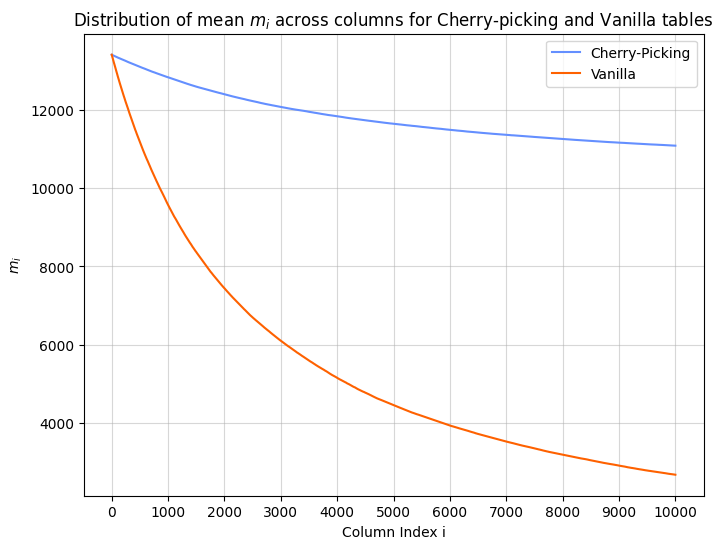

In [58]:
## Plot m_values for cherry and vanilla
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

plt.figure(figsize=(8, 6))

x_indicies = np.arange(t + 1)  # x values from 0 to 256
cherry_m_values_array = np.array(np.mean(cherry_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, cherry_m_values_array, color='#648fff', label="Cherry-Picking", markersize=5)

vanilla_m_values_array = np.array(np.mean(vanilla_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, vanilla_m_values_array, color='#FE6100', label="Vanilla", markersize=5)

ax = plt.gca()

ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))
plt.grid(visible=True, which='both', axis='both', alpha = 0.5)



plt.xlabel("Column Index i")
plt.ylabel(r"$m_i$")
plt.title(r"Distribution of mean $m_i$ across columns for Cherry-picking and Vanilla tables")
plt.legend()
# plt.grid()
# save as svg
plt.savefig(f"m_values_distribution_t_{t}.eps", format='eps', bbox_inches='tight')
plt.show()

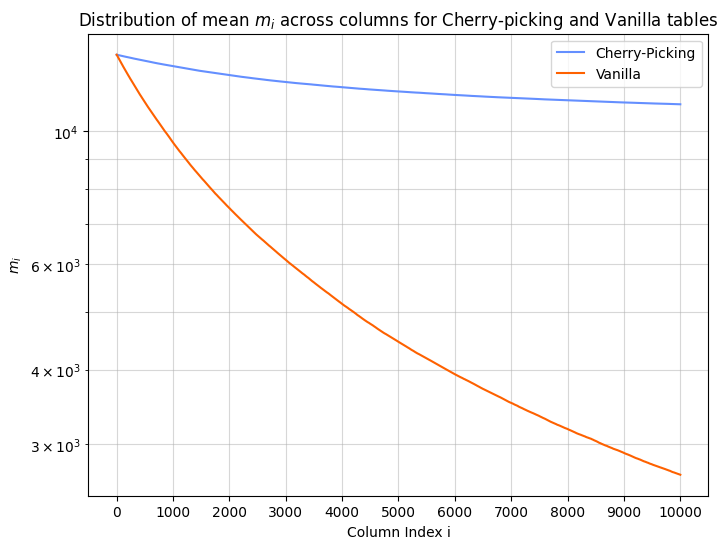

In [62]:
## Plot m_values for cherry and vanilla
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import LogLocator, LogFormatterMathtext

plt.figure(figsize=(8, 6))

x_indicies = np.arange(t + 1)  # x values from 0 to 256
cherry_m_values_array = np.array(np.mean(cherry_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, cherry_m_values_array, color='#648fff', label="Cherry-Picking", markersize=5)

vanilla_m_values_array = np.array(np.mean(vanilla_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, vanilla_m_values_array, color='#FE6100', label="Vanilla", markersize=5)

ax = plt.gca()
ax.set_yscale('log')

# Force ticks only at integer powers of 10 (e.g., 10^0, 10^1, 10^2)
ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=10))
# Ensure they display nicely as 10^x
ax.yaxis.set_major_formatter(LogFormatterMathtext())

ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))
plt.grid(visible=True, which='both', axis='both', alpha = 0.5)
# plt.grid(visible=True, which='major', axis='both', alpha=0.5)
# plt.grid(visible=True, which='minor', axis='y', alpha=0.2)



plt.xlabel("Column Index i")
plt.ylabel(r"$m_i$")
plt.title(r"Distribution of mean $m_i$ across columns for Cherry-picking and Vanilla tables")
plt.legend()
# plt.grid()
# save as svg
# plt.savefig("m_values_distribution.eps", format='eps', bbox_inches='tight')
plt.show()

In [64]:
## success prob
ch_sp = 1 - ((1 - (cherry_avg_mt / 2**24)) ** t)
van_sp = 1 - ((1 - (vanilla_avg_mt / 2**24)) ** t)

print(f"Success probability of cherry: {ch_sp}")
print(f"Success probability of vanilla: {van_sp}")

Success probability of cherry: 0.9986574383265293
Success probability of vanilla: 0.7964672489933474
